In [1]:
import pandas as pd
pd.set_option("future.infer_string", False)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pypsa
import warnings
warnings.filterwarnings("ignore")

YEARS = [2015, 2016, 2017, 2018, 2019]
TECHS = ["Onshore Wind", "Offshore Wind", "Solar PV", "OCGT", "Coal", "Nuclear"]
COLORS = {
    "Onshore Wind" : "#4575b4",
    "Offshore Wind": "#74add1",
    "Solar PV"     : "#fee090",
    "OCGT"         : "#d73027",
    "Coal"         : "#525252",
    "Nuclear"      : "#7b2d8b",
}


In [2]:
# ── 1. Annuity helper ─────────────────────────────────────────────────────────
def annuity(n, r):
    if r > 0:
        return r / (1.0 - 1.0 / (1.0 + r) ** n)
    return 1.0 / n

# ── 2. Cost parameters (identical across all years) ──────────────────────────
r       = 0.07
usd_eur = 1 / 1.13   # ECB 2017 average

cap_onshore  = annuity(30, r) * 910_000   * (1 + 0.033)
cap_offshore = annuity(25, r) * 2_506_000 * (1 + 0.030)
cap_solar    = annuity(25, r) * 425_000   * (1 + 0.030)
cap_ocgt     = annuity(25, r) * 560_000   * (1 + 0.033)
cap_coal     = annuity(40, r) * 2_133_000 * usd_eur
cap_nuclear  = annuity(60, r) * 4_101_000 * usd_eur

mc_ocgt    = 21.6 / 0.39
mc_coal    = 8.5  / 0.41 + 4.0
mc_nuclear = 3.5  / 0.33 + 12.0

In [3]:
# ── 3. Load raw data ──────────────────────────────────────────────────────────
print("Loading data...")
df_raw = pd.read_csv("Data.csv", parse_dates=["cet_cest_timestamp"], low_memory=False)
df_raw = df_raw.set_index("cet_cest_timestamp")
df_raw = df_raw.apply(pd.to_numeric, errors="coerce")

# ── 4. Helper: prepare one year's data ───────────────────────────────────────
def prepare_year(df_raw, year):
    df = df_raw[df_raw.index.year == year].copy()
    df = df[df["load"] > 0]
    df = df[~df.index.duplicated(keep="first")]
    hours = pd.date_range(f"{year}-01-01 00:00", f"{year}-12-31 23:00", freq="h")
    df = df.reindex(hours).interpolate(method="time")
    # Clip CFs to [0, 1]
    for col in ["Solar Profile", "Wind_Onshore Profile", "Wind_Offshore Profile"]:
        df[col] = df[col].clip(0, 1)
    return df

Loading data...


In [4]:
# ── 5. Helper: build and optimise one network ─────────────────────────────────
def run_year(year, df):
    print(f"  Optimising {year}...")
    n = pypsa.Network()
    n.set_snapshots(df.index)

    n.add("Bus", "DE electricity")
    n.add("Carrier", "onshorewind")
    n.add("Carrier", "offshorewind")
    n.add("Carrier", "solar")
    n.add("Carrier", "gas",     co2_emissions=0.19)
    n.add("Carrier", "coal",    co2_emissions=0.34)
    n.add("Carrier", "nuclear", co2_emissions=0.0)

    n.add("Load", "demand", bus="DE electricity", p_set=df["load"].values)

    n.add("Generator", "Onshore Wind",  bus="DE electricity", p_nom_extendable=True,
          carrier="onshorewind",  capital_cost=cap_onshore,  marginal_cost=0,
          p_max_pu=df["Wind_Onshore Profile"].values)
    n.add("Generator", "Offshore Wind", bus="DE electricity", p_nom_extendable=True,
          carrier="offshorewind", capital_cost=cap_offshore, marginal_cost=0,
          p_max_pu=df["Wind_Offshore Profile"].values)
    n.add("Generator", "Solar PV",      bus="DE electricity", p_nom_extendable=True,
          carrier="solar",        capital_cost=cap_solar,    marginal_cost=0,
          p_max_pu=df["Solar Profile"].values)
    n.add("Generator", "OCGT",          bus="DE electricity", p_nom_extendable=True,
          carrier="gas",          capital_cost=cap_ocgt,     marginal_cost=mc_ocgt)
    n.add("Generator", "Coal",          bus="DE electricity", p_nom_extendable=True,
          carrier="coal",         capital_cost=cap_coal,     marginal_cost=mc_coal)
    n.add("Generator", "Nuclear",       bus="DE electricity", p_nom_extendable=True,
          carrier="nuclear",      capital_cost=cap_nuclear,  marginal_cost=mc_nuclear)

    n.optimize(solver_name="gurobi")
    return n


In [ ]:
# ── 6. Run all years ──────────────────────────────────────────────────────────
print("\nRunning optimisation for each weather year...")
results = {}
for yr in YEARS:
    df_yr = prepare_year(df_raw, yr)
    network = run_year(yr, df_yr)
    cap_opt = network.generators.p_nom_opt  # MW

    # Annual generation per tech [TWh]
    gen = network.generators_t.p.sum() / 1e6

    # Annual capacity factor
    cf = {}
    for t in TECHS:
        c = cap_opt.get(t, 0)
        cf[t] = gen.get(t, 0) * 1e6 / (c * len(df_yr)) if c > 1 else 0

    results[yr] = {
        "cap_GW": cap_opt / 1000,
        "gen_TWh": gen,
        "cf": pd.Series(cf),
        "lcoe": network.objective / network.loads_t.p.sum().values[0],
        "total_cost_B": network.objective / 1e9,
    }
    print(f"    {yr} LCOE: {results[yr]['lcoe']:.1f} €/MWh | "
          f"Total cost: {results[yr]['total_cost_B']:.2f} B€/yr")


Running optimisation for each weather year...
  Optimising 2015...


Index(['DE electricity'], dtype='object', name='name')
DatetimeIndex(['2015-01-01 00:00:00'], dtype='datetime64[ns]', name='snapshot', freq='h')
DatetimeIndex(['2015-01-01 00:00:00'], dtype='datetime64[ns]', name='snapshot', freq='h')
DatetimeIndex(['2015-01-01 00:00:00', '2015-01-01 01:00:00',
               '2015-01-01 02:00:00', '2015-01-01 03:00:00',
               '2015-01-01 04:00:00', '2015-01-01 05:00:00',
               '2015-01-01 06:00:00', '2015-01-01 07:00:00'],
              dtype='datetime64[ns]', name='snapshot', freq='h')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 140.51it/s]
INFO:linopy.io: Writing time: 0.21s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2775732


...

INFO:gurobipy:


Solved in 17551 iterations and 2.35 seconds (1.05 work units)


INFO:gurobipy:Solved in 17551 iterations and 2.35 seconds (1.05 work units)


Optimal objective  2.195934182e+10


INFO:gurobipy:Optimal objective  2.195934182e+10


In [ ]:
# ── 7. Assemble summary DataFrames ────────────────────────────────────────────
cap_df  = pd.DataFrame({yr: results[yr]["cap_GW"]  for yr in YEARS}).T   # [GW]
gen_df  = pd.DataFrame({yr: results[yr]["gen_TWh"] for yr in YEARS}).T   # [TWh]
cf_df   = pd.DataFrame({yr: results[yr]["cf"]      for yr in YEARS}).T
lcoe_s  = pd.Series({yr: results[yr]["lcoe"]       for yr in YEARS})

# Keep only techs that have non-zero capacity in at least one year
active_techs = cap_df.columns[(cap_df > 0.01).any()].tolist()
# Preserve defined order
active_techs = [t for t in TECHS if t in active_techs]

cap_df  = cap_df[active_techs]
gen_df  = gen_df[active_techs]
cf_df   = cf_df[active_techs]

print("\n── Optimal capacities [GW] ──")
print(cap_df.round(2).to_string())
print("\n── Annual generation [TWh] ──")
print(gen_df.round(1).to_string())
print("\n── Capacity factors [–] ──")
print(cf_df.round(3).to_string())


── Optimal capacities [GW] ──
name  Onshore Wind  Solar PV   OCGT   Coal
2015         45.69     10.31  22.57  47.48
2016          7.36      7.30  15.81  59.06
2017         21.95     13.03  20.21  54.60
2018         17.36     13.57  15.01  57.03
2019         20.48      7.74  18.11  55.76

── Annual generation [TWh] ──
name  Onshore Wind  Solar PV  OCGT   Coal
2015         110.6       9.5  23.4  335.9
2016          14.8       6.4  14.8  451.0
2017          50.8      11.4  17.3  412.5
2018          37.2      12.6  14.0  435.1
2019          46.2       6.5  16.3  421.4

── Capacity factors [–] ──
      Onshore Wind  Solar PV   OCGT   Coal
2015         0.276     0.105  0.118  0.808
2016         0.230     0.100  0.106  0.869
2017         0.264     0.100  0.098  0.862
2018         0.244     0.106  0.107  0.871
2019         0.258     0.096  0.103  0.863



Plotting figures...


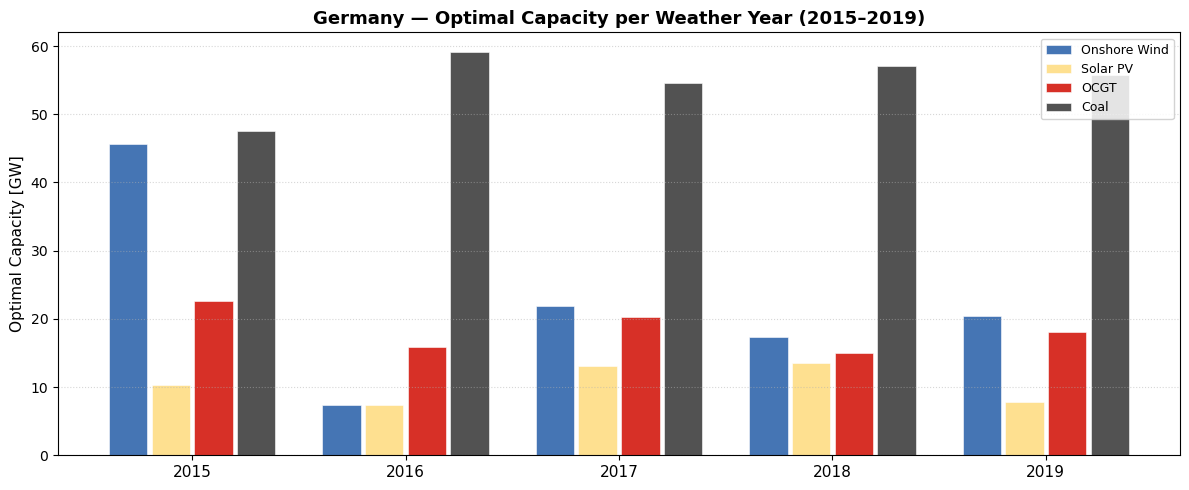

  Saved: sensitivity_capacity_by_year.png


In [ ]:
# ── 8. Plot 1: Optimal capacities per year (grouped bar) ──────────────────────
print("\nPlotting figures...")
fig, ax = plt.subplots(figsize=(12, 5))
x     = np.arange(len(YEARS))
n_t   = len(active_techs)
width = 0.8 / n_t

for i, tech in enumerate(active_techs):
    offset = (i - n_t / 2 + 0.5) * width
    vals   = cap_df[tech].values
    bars   = ax.bar(x + offset, vals, width=width * 0.9,
                    color=COLORS[tech], label=tech, edgecolor="white", linewidth=0.4)

ax.set_xticks(x)
ax.set_xticklabels(YEARS, fontsize=11)
ax.set_ylabel("Optimal Capacity [GW]", fontsize=11)
ax.set_title("Germany — Optimal Capacity per Weather Year (2015–2019)",
             fontsize=13, fontweight="bold")
ax.legend(loc="upper right", fontsize=9, framealpha=0.85)
ax.grid(axis="y", linestyle=":", alpha=0.5)
ax.set_ylim(0)
plt.tight_layout()
plt.savefig("sensitivity_capacity_by_year.png", dpi=150)
plt.show()
print("  Saved: sensitivity_capacity_by_year.png")

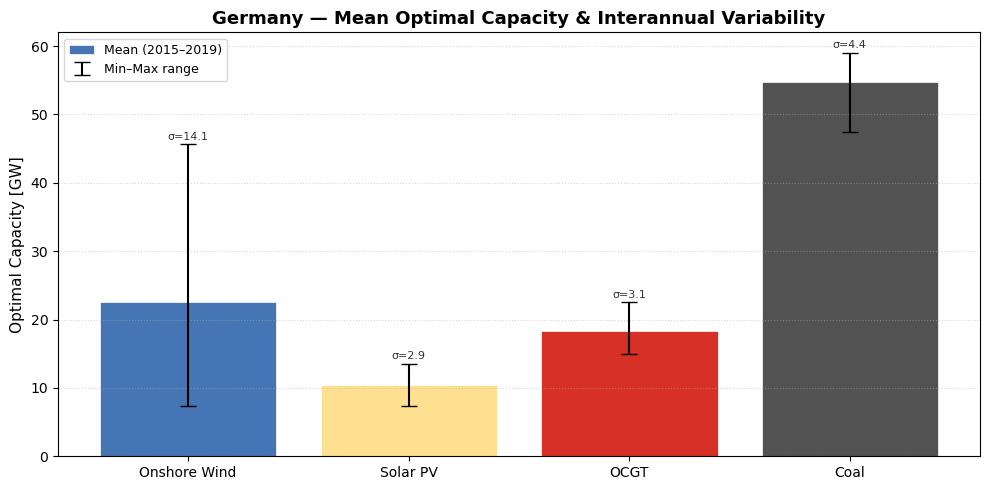

  Saved: sensitivity_mean_variability.png


In [ ]:
# ── 9. Plot 2: Mean capacity + variability (error bar) ────────────────────────
cap_mean = cap_df.mean()
cap_std  = cap_df.std()
cap_min  = cap_df.min()
cap_max  = cap_df.max()

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(active_techs))
colors_list = [COLORS[t] for t in active_techs]

bars = ax.bar(x, cap_mean.values, color=colors_list,
              edgecolor="white", linewidth=0.5, label="Mean (2015–2019)")
ax.errorbar(x, cap_mean.values,
            yerr=[cap_mean.values - cap_min.values,
                  cap_max.values - cap_mean.values],
            fmt="none", color="black", capsize=6, linewidth=1.5,
            label="Min–Max range")

# Annotate std on each bar
for xi, (m, s) in enumerate(zip(cap_mean.values, cap_std.values)):
    if m > 0.05:
        ax.text(xi, m + (cap_max.values[xi] - m) + 0.3,
                f"σ={s:.1f}", ha="center", va="bottom", fontsize=8, color="#333333")

ax.set_xticks(x)
ax.set_xticklabels(active_techs, fontsize=10)
ax.set_ylabel("Optimal Capacity [GW]", fontsize=11)
ax.set_title("Germany — Mean Optimal Capacity & Interannual Variability",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(axis="y", linestyle=":", alpha=0.5)
ax.set_ylim(0)
plt.tight_layout()
plt.savefig("sensitivity_mean_variability.png", dpi=150)
plt.show()
print("  Saved: sensitivity_mean_variability.png")

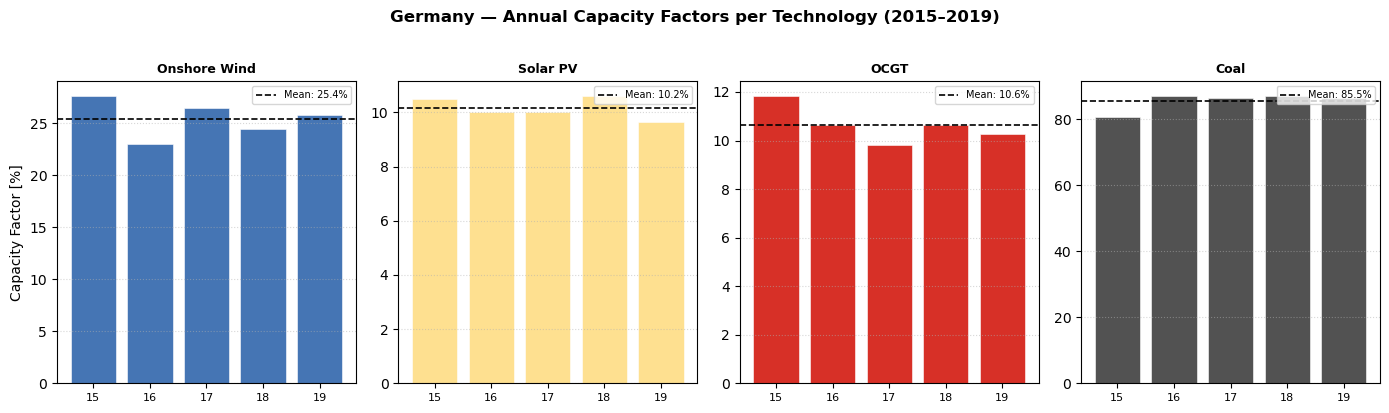

  Saved: sensitivity_capacity_factors.png


In [ ]:
# ── 10. Plot 3: Capacity factor variability per technology ─────────────────────
fig, axes = plt.subplots(1, len(active_techs), figsize=(14, 4), sharey=False)
if len(active_techs) == 1:
    axes = [axes]

for ax, tech in zip(axes, active_techs):
    vals = cf_df[tech].values * 100   # → percent
    ax.bar(YEARS, vals, color=COLORS[tech], edgecolor="white", linewidth=0.4)
    ax.axhline(cf_df[tech].mean() * 100, color="black",
               linestyle="--", linewidth=1.2, label=f"Mean: {cf_df[tech].mean()*100:.1f}%")
    ax.set_title(tech, fontsize=9, fontweight="bold")
    ax.set_ylabel("Capacity Factor [%]" if tech == active_techs[0] else "")
    ax.set_xticks(YEARS)
    ax.set_xticklabels([str(y)[2:] for y in YEARS], fontsize=8)
    ax.legend(fontsize=7, loc="upper right")
    ax.grid(axis="y", linestyle=":", alpha=0.5)
    ax.set_ylim(0)

plt.suptitle("Germany — Annual Capacity Factors per Technology (2015–2019)",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("sensitivity_capacity_factors.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Saved: sensitivity_capacity_factors.png")

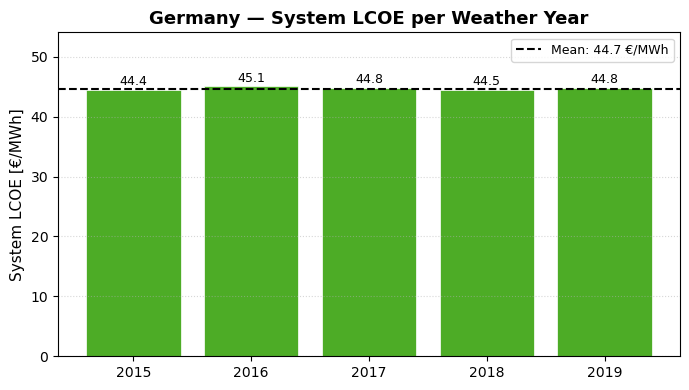

  Saved: sensitivity_lcoe.png


In [ ]:
# ── 11. Plot 4: LCOE per year ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(YEARS, lcoe_s.values, color="#4dac26", edgecolor="white", linewidth=0.5)
ax.axhline(lcoe_s.mean(), color="black", linestyle="--",
           linewidth=1.5, label=f"Mean: {lcoe_s.mean():.1f} €/MWh")
for yr, val in zip(YEARS, lcoe_s.values):
    ax.text(yr, val + 0.3, f"{val:.1f}", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("System LCOE [€/MWh]", fontsize=11)
ax.set_title("Germany — System LCOE per Weather Year", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.set_ylim(0, lcoe_s.max() * 1.2)
ax.grid(axis="y", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.savefig("sensitivity_lcoe.png", dpi=150)
plt.show()
print("  Saved: sensitivity_lcoe.png")

In [ ]:
# ── 12. Summary table ─────────────────────────────────────────────────────────
print("\n" + "="*75)
print("SUMMARY — INTERANNUAL SENSITIVITY (2015–2019)")
print("="*75)
print(f"\n{'Technology':<18} {'Mean [GW]':>10} {'Std [GW]':>10} {'Min [GW]':>10} {'Max [GW]':>10} {'CoV [%]':>9}")
print("-"*75)
for tech in active_techs:
    m = cap_mean[tech]; s = cap_std[tech]
    mn = cap_min[tech]; mx = cap_max[tech]
    cov = (s / m * 100) if m > 0.01 else 0
    print(f"  {tech:<16} {m:>10.2f} {s:>10.2f} {mn:>10.2f} {mx:>10.2f} {cov:>8.1f}%")
print("-"*75)
print(f"\n{'Year':<8} {'LCOE [€/MWh]':>14}")
for yr, val in lcoe_s.items():
    print(f"  {yr}   {val:>12.1f}")
print(f"  Mean  {lcoe_s.mean():>12.1f}  ±{lcoe_s.std():.1f}")
print("="*75)


SUMMARY — INTERANNUAL SENSITIVITY (2015–2019)

Technology          Mean [GW]   Std [GW]   Min [GW]   Max [GW]   CoV [%]
---------------------------------------------------------------------------
  Onshore Wind          22.57      14.12       7.36      45.69     62.6%
  Solar PV              10.39       2.90       7.30      13.57     27.9%
  OCGT                  18.34       3.12      15.01      22.57     17.0%
  Coal                  54.79       4.41      47.48      59.06      8.0%
---------------------------------------------------------------------------

Year       LCOE [€/MWh]
  2015           44.4
  2016           45.1
  2017           44.8
  2018           44.5
  2019           44.8
  Mean          44.7  ±0.3
